In [5]:
# AI-Assisted Customer Insights Pipeline
# Amazon Reviews Project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# -----------------------------
# 1. Load Data
# -----------------------------

negative_path = "negative_review_sample.csv"
positive_path = "positive_review_sample.csv"

df_neg = pd.read_csv(negative_path)
df_pos = pd.read_csv(positive_path)

df_neg["sentiment_group"] = "negative"
df_pos["sentiment_group"] = "positive"

df = pd.concat([df_neg, df_pos], ignore_index=True)

print(df.shape)
df.head()

(20000, 2)


,review_text,sentiment_group
0,"I have an absolute passion for deep, dark hot ...",negative
1,"This drink is so ""super energy"" it's almost fr...",negative
2,"I'm sticking with what used to be carnation, n...",negative
3,Aspertame causes alot of problems including pr...,negative
4,I ordered these because my local pet store sto...,negative


In [ ]:
# -----------------------------
# 2. Clean Data
# -----------------------------

# make column names easier to work with
df.columns = df.columns.str.strip()

# if your review column is named differently, this checks common options
possible_text_cols = ["review_text", "Text", "text", "review", "Review"]

text_col = None
for col in possible_text_cols:
    if col in df.columns:
        text_col = col
        break

if text_col is None:
    raise ValueError(f"No review text column found. Columns are: {df.columns.tolist()}")

df = df.dropna(subset=[text_col])
df[text_col] = df[text_col].astype(str)

df["review_length"] = df[text_col].apply(len)

df = df[df["review_length"] > 20]
def clean_review_text(text):
    text = re.sub(r"<.*?>", " ", str(text))
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text

df["clean_text"] = df["review_text"].apply(clean_review_text)
print(df.shape)
df.head()

(20000, 4)


,review_text,sentiment_group,review_length,clean_text
0,"I have an absolute passion for deep, dark hot ...",negative,582,i have an absolute passion for deep dark hot c...
1,"This drink is so ""super energy"" it's almost fr...",negative,244,this drink is so super energy it s almost frig...
2,"I'm sticking with what used to be carnation, n...",negative,119,i m sticking with what used to be carnation no...
3,Aspertame causes alot of problems including pr...,negative,615,aspertame causes alot of problems including pr...
4,I ordered these because my local pet store sto...,negative,279,i ordered these because my local pet store sto...


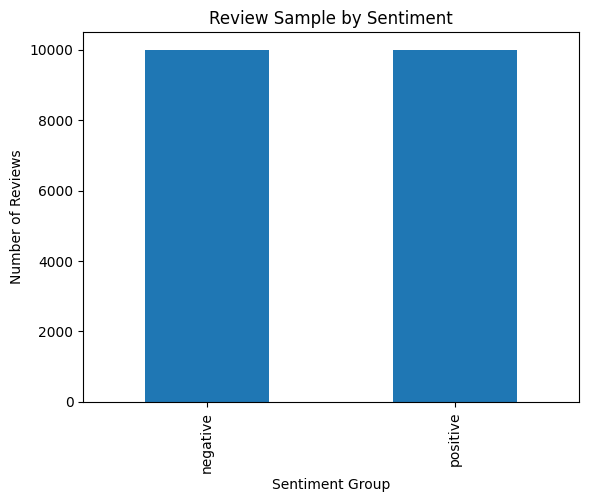

sentiment_group
negative    10000
positive    10000
Name: count, dtype: int64

In [7]:
# -----------------------------
# 3. Basic Sentiment Counts
# -----------------------------

sentiment_counts = df["sentiment_group"].value_counts()

sentiment_counts.plot(kind="bar")
plt.title("Review Sample by Sentiment")
plt.xlabel("Sentiment Group")
plt.ylabel("Number of Reviews")
plt.show()

sentiment_counts

In [8]:
# -----------------------------
# 4. TF-IDF Vectorization
# -----------------------------

vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.85
)

X = vectorizer.fit_transform(df["clean_text"])

print(X.shape)

(20000, 3000)


In [9]:
# -----------------------------
# 5. KMeans Clustering
# -----------------------------

k = 10

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X)

df[["sentiment_group", "cluster", text_col]].head()

,sentiment_group,cluster,review_text
0,negative,2,"I have an absolute passion for deep, dark hot ..."
1,negative,9,"This drink is so ""super energy"" it's almost fr..."
2,negative,9,"I'm sticking with what used to be carnation, n..."
3,negative,9,Aspertame causes alot of problems including pr...
4,negative,5,I ordered these because my local pet store sto...


In [10]:
# -----------------------------
# 6. Top Terms by Cluster
# -----------------------------

terms = vectorizer.get_feature_names_out()

def get_top_terms(cluster_num, n=15):
    center = kmeans.cluster_centers_[cluster_num]
    top_indices = center.argsort()[-n:][::-1]
    return [terms[i] for i in top_indices]

cluster_terms = {}

for i in range(k):
    top_terms = get_top_terms(i)
    cluster_terms[i] = top_terms
    print(f"\nCluster {i}")
    print(top_terms)


Cluster 0
['chips', 'potato', 'kettle', 'bag', 'potato chips', 'like', 'taste', 'salt', 'chip', 'flavor', 'just', 'great', 'bags', 'love', 'salty']

Cluster 1
['tea', 'green', 'teas', 'green tea', 'like', 'taste', 'flavor', 'drink', 'good', 'bags', 'love', 'cup', 'tea bags', 'just', 'stash']

Cluster 2
['chocolate', 'dark chocolate', 'dark', 'cookies', 'hot chocolate', 'hot', 'like', 'flavor', 'cocoa', 'bar', 'taste', 'milk', 'good', 'bars', 'just']

Cluster 3
['great', 'good', 'just', 'love', 'flavor', 'product', 'use', 'like', 'best', 'buy', 'time', 'little', 'bought', 'eat', 'really']

Cluster 4
['gluten', 'gluten free', 'free', 'peanut', 'butter', 'peanut butter', 'cookies', 'good', 'taste', 'like', 'great', 'bars', 'love', 'cookie', 'eat']

Cluster 5
['product', 'amazon', 'price', 'order', 'box', 'store', 'ordered', 'shipping', 'buy', 'received', 'great', 'item', 'good', 'grocery', 'local']

Cluster 6
['dog', 'dogs', 'treats', 'food', 'treat', 'dog food', 'loves', 'eat', 'love', 

In [12]:
# -----------------------------
# 7. Sample Reviews by Cluster
# -----------------------------

for i in range(k):
    print(f"\n==============================================")
    print(f"CLUSTER {i}")
    print(f"Top terms: {cluster_terms[i]}")
    print("===============================================")
    
    sample_reviews = df[df["cluster"] == i][text_col].sample(
        min(5, len(df[df["cluster"] == i])),
        random_state=42
    )
    
    for review in sample_reviews:
        print("-", review[:500])
        print()


CLUSTER 0
Top terms: ['chips', 'potato', 'kettle', 'bag', 'potato chips', 'like', 'taste', 'salt', 'chip', 'flavor', 'just', 'great', 'bags', 'love', 'salty']
- I really do recommend Pop Chips.  If you are looking for the 100 calorie snack this is it.  They taste great.

- Tried both chips. Turbana is so good. Sweeter. With full chips, Not a bag of crumbs like Samai chips.  Samai needs to stop holding out the plaintains and I dont think they are as healthy.  Turbana bakes their chips.

- Love these pop chips----low fat and calories and yummy flavor.  Will definitely be ordering again!!!

- These are some of the most delicious snacks that I have tasted!It is amazing that the serving size is comparable to regular chips but only 100 calories.

- It is addictive! I always end up eating the whole chips, so I plan to buy a dehydrate soon to make my own.<br />Pretty sure you can make your own like this one :D


CLUSTER 1
Top terms: ['tea', 'green', 'teas', 'green tea', 'like', 'taste', 'flav

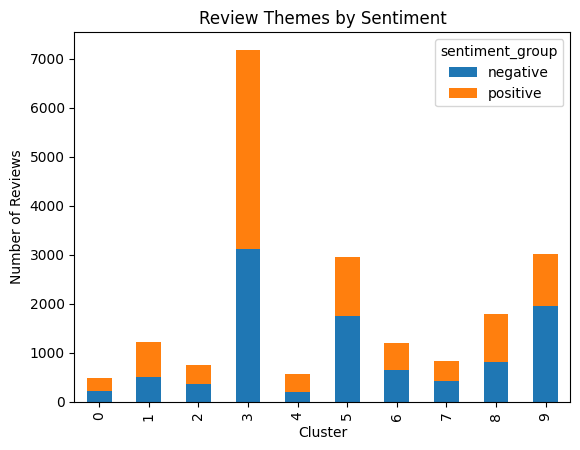

sentiment_group,negative,positive
cluster,,
0,215,274
1,514,697
2,364,389
3,3116,4063
4,198,362
5,1755,1198
6,640,569
7,430,403
8,822,974


In [22]:
# -----------------------------
# 8. Cluster Distribution by Sentiment
# -----------------------------

cluster_summary = df.groupby(["cluster", "sentiment_group"]).size().unstack(fill_value=0)

cluster_summary.plot(kind="bar", stacked=True)
plt.title("Review Themes by Sentiment")
plt.xlabel("Cluster")
plt.ylabel("Number of Reviews")
plt.show()

cluster_summary

In [ ]:
# -----------------------------
# 9. Add Human/AI-Labeled Cluster Names
# -----------------------------
# after reviewing cluster terms sample reviews, manually label clusters here
# replace these names with your final ai-assisted labels

cluster_labels = {
    0: "General Taste & Product Experience",
    1: "Tea Flavor & Brew Strength",
    2: "Coffee Quality & Strength",
    3: "Review Metadata / Listing Noise",
    4: "General Snack Satisfaction",
    5: "Dog Food & Treat Acceptance",
    6: "Cat Food Health & Acceptance",
    7: "Mixed Product Experience / Ingredients",
    8: "Price, Ordering, Shipping & Availability",
    9: "Chocolate, Gluten-Free & Snack Products"
}

df["theme"] = df["cluster"].map(cluster_labels)

df[["sentiment_group", "cluster", "theme", text_col]].head()

,sentiment_group,cluster,theme,review_text
0,negative,2,Coffee Quality & Strength,"I have an absolute passion for deep, dark hot ..."
1,negative,9,"Chocolate, Gluten-Free & Snack Products","This drink is so ""super energy"" it's almost fr..."
2,negative,9,"Chocolate, Gluten-Free & Snack Products","I'm sticking with what used to be carnation, n..."
3,negative,9,"Chocolate, Gluten-Free & Snack Products",Aspertame causes alot of problems including pr...
4,negative,5,Dog Food & Treat Acceptance,I ordered these because my local pet store sto...


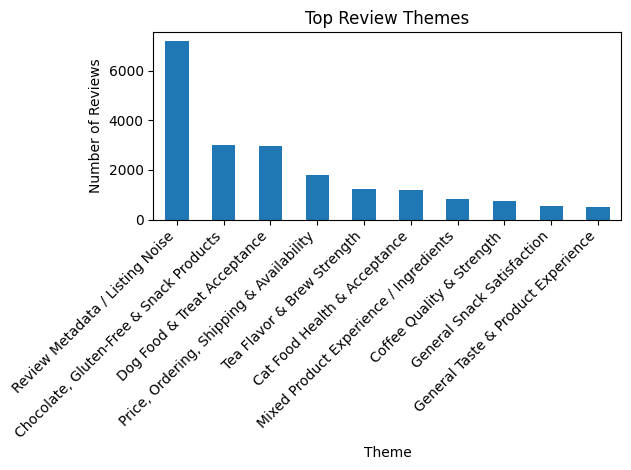

theme
Review Metadata / Listing Noise             7179
Chocolate, Gluten-Free & Snack Products     3017
Dog Food & Treat Acceptance                 2953
Price, Ordering, Shipping & Availability    1796
Tea Flavor & Brew Strength                  1211
Cat Food Health & Acceptance                1209
Mixed Product Experience / Ingredients       833
Coffee Quality & Strength                    753
General Snack Satisfaction                   560
General Taste & Product Experience           489
Name: count, dtype: int64

In [35]:
# -----------------------------
# 10. Theme Counts
# -----------------------------

theme_counts = df["theme"].value_counts()

theme_counts.plot(kind="bar")
plt.title("Top Review Themes")
plt.xlabel("Theme")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

theme_counts

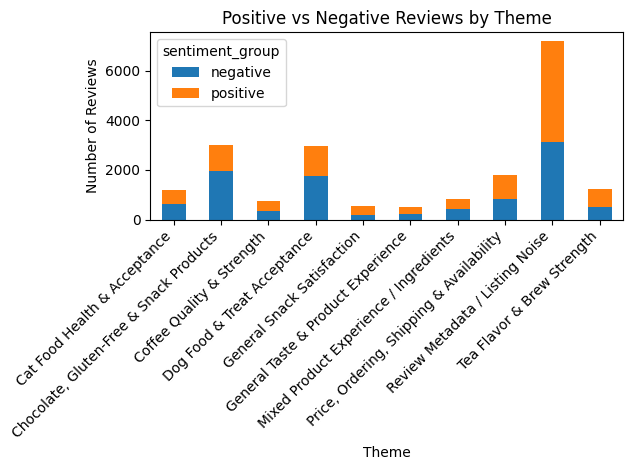

sentiment_group,negative,positive
theme,,
Cat Food Health & Acceptance,640,569
"Chocolate, Gluten-Free & Snack Products",1946,1071
Coffee Quality & Strength,364,389
Dog Food & Treat Acceptance,1755,1198
General Snack Satisfaction,198,362
General Taste & Product Experience,215,274
Mixed Product Experience / Ingredients,430,403
"Price, Ordering, Shipping & Availability",822,974
Review Metadata / Listing Noise,3116,4063


In [36]:
# -----------------------------
# 11. Positive vs Negative by Theme
# -----------------------------

theme_sentiment = df.groupby(["theme", "sentiment_group"]).size().unstack(fill_value=0)

theme_sentiment.plot(kind="bar", stacked=True)
plt.title("Positive vs Negative Reviews by Theme")
plt.xlabel("Theme")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

theme_sentiment

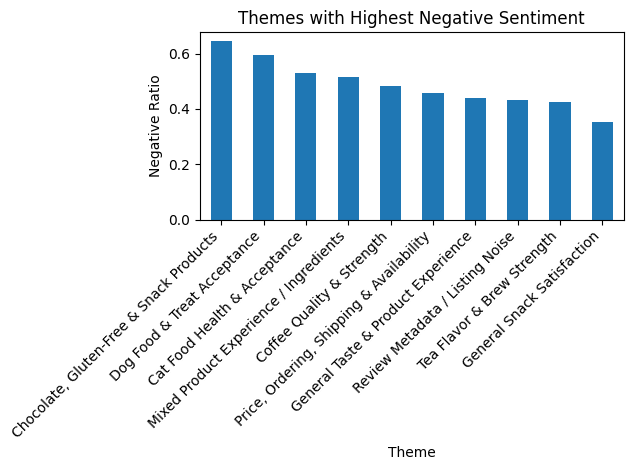

sentiment_group,negative,positive,negative_ratio
theme,,,
"Chocolate, Gluten-Free & Snack Products",1946,1071,0.645012
Dog Food & Treat Acceptance,1755,1198,0.594311
Cat Food Health & Acceptance,640,569,0.529363
Mixed Product Experience / Ingredients,430,403,0.516206
Coffee Quality & Strength,364,389,0.483400
"Price, Ordering, Shipping & Availability",822,974,0.457684
General Taste & Product Experience,215,274,0.439673
Review Metadata / Listing Noise,3116,4063,0.434044
Tea Flavor & Brew Strength,514,697,0.424443


In [ ]:
# -----------------------------
# 12. Themes with Highest Negative Sentiment Ratio
# -----------------------------

theme_sentiment["negative_ratio"] = (
    theme_sentiment["negative"] /
    (theme_sentiment["negative"] + theme_sentiment["positive"])
)

top_negative = theme_sentiment.sort_values("negative_ratio", ascending=False)

top_negative["negative_ratio"].plot(kind="bar")
plt.title("Themes with Highest Negative Sentiment")
plt.xlabel("Theme")
plt.ylabel("Negative Ratio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top_negative

In [ ]:
# -----------------------------
# 13. Export LLM Cluster Review Pack
# -----------------------------
# this creates a file to upload into LLM for final theme labeling

with open("cluster_review_samples_for_llm.txt", "w", encoding="utf-8") as f:
    for i in range(k):
        f.write(f"\n==============================\n")
        f.write(f"CLUSTER {i}\n")
        f.write(f"Top terms: {cluster_terms[i]}\n")
        f.write(f"==============================\n")
        
        sample_reviews = df[df["cluster"] == i][text_col].sample(
            min(10, len(df[df["cluster"] == i])),
            random_state=42
        )
        
        for review in sample_reviews:
            f.write(f"- {review[:700]}\n\n")

print("Exported: cluster_review_samples_for_llm.txt")

Exported: cluster_review_samples_for_llm.txt


In [ ]:
# -----------------------------
# 14. Business Recommendations Table
# -----------------------------

recommendations = pd.DataFrame({
    "Theme": [
        "Chips & Snack Satisfaction",
        "Tea Flavor & Brew Strength",
        "Chocolate & Sweet Snack Experience",
        "General Product Satisfaction / Value Issues",
        "Gluten-Free & Peanut Butter Products",
        "Price, Ordering, Shipping & Availability",
        "Dog Food & Treat Acceptance",
        "Cat Food Health & Acceptance",
        "Coffee Quality & Strength",
        "General Taste & Flavor Complaints"
    ],
    "Business Interpretation": [
        "Snack products are driven heavily by taste, texture, and perceived health/value balance.",
        "Tea satisfaction depends on flavor strength, aroma consistency, and proper brewing expectations.",
        "Chocolate and sweet snacks are judged on richness, sweetness balance, and texture quality.",
        "Mixed reviews often stem from mismatched expectations around product quality and perceived value.",
        "Specialty dietary products must meet both taste expectations and strict ingredient requirements.",
        "Logistics issues (shipping delays, damage, incorrect items) strongly impact customer satisfaction independent of product quality.",
        "Dog product success is highly dependent on pet acceptance, digestibility, and perceived safety.",
        "Cat food performance is closely tied to health outcomes, ingredient trust, and pet preference.",
        "Coffee reviews are highly sensitive to strength, freshness, roast profile, and brewing compatibility.",
        "General dissatisfaction is often driven by unnatural taste, weak flavor, or off-putting texture."
    ],
    "Recommendation": [
        "Focus on optimizing flavor profiles and highlight health/value positioning in snack marketing.",
        "Provide clearer brewing instructions and ensure flavor consistency across batches.",
        "Refine sweetness levels and improve texture consistency for chocolate products.",
        "Align pricing with perceived value and improve product descriptions to set accurate expectations.",
        "Ensure ingredient transparency and improve flavor quality in specialty diet products.",
        "Improve packaging durability, shipping speed, and accuracy of product fulfillment.",
        "Increase product testing for palatability and safety across a wide range of dogs.",
        "Prioritize high-quality ingredients and communicate health benefits clearly for cat products.",
        "Optimize roast consistency and clearly communicate strength/flavor expectations.",
        "Reformulate products with poor taste feedback and ensure natural, appealing flavor profiles."
    ]
})

recommendations

,Theme,Business Interpretation,Recommendation
0,Chips & Snack Satisfaction,"Snack products are driven heavily by taste, te...",Focus on optimizing flavor profiles and highli...
1,Tea Flavor & Brew Strength,"Tea satisfaction depends on flavor strength, a...",Provide clearer brewing instructions and ensur...
2,Chocolate & Sweet Snack Experience,Chocolate and sweet snacks are judged on richn...,Refine sweetness levels and improve texture co...
3,General Product Satisfaction / Value Issues,Mixed reviews often stem from mismatched expec...,Align pricing with perceived value and improve...
4,Gluten-Free & Peanut Butter Products,Specialty dietary products must meet both tast...,Ensure ingredient transparency and improve fla...
5,"Price, Ordering, Shipping & Availability","Logistics issues (shipping delays, damage, inc...","Improve packaging durability, shipping speed, ..."
6,Dog Food & Treat Acceptance,Dog product success is highly dependent on pet...,Increase product testing for palatability and ...
7,Cat Food Health & Acceptance,Cat food performance is closely tied to health...,Prioritize high-quality ingredients and commun...
8,Coffee Quality & Strength,Coffee reviews are highly sensitive to strengt...,Optimize roast consistency and clearly communi...
9,General Taste & Flavor Complaints,General dissatisfaction is often driven by unn...,Reformulate products with poor taste feedback ...


In [ ]:
# -----------------------------
# 15. Export Final Files
# -----------------------------

df.to_csv("classified_amazon_reviews.csv", index=False)
theme_sentiment.to_csv("theme_sentiment_summary.csv")
recommendations.to_csv("business_recommendations.csv", index=False)

print("Saved:")
print("classified_amazon_reviews.csv")
print("theme_sentiment_summary.csv")
print("business_recommendations.csv")

Saved:
classified_amazon_reviews.csv
theme_sentiment_summary.csv
business_recommendations.csv
